### 1. Loading and Preprocessing
#### The Diabetes dataset is a regression dataset.
##### No missing values (already cleaned in sklearn).
##### Normalization is important because ANN works best when inputs are on the same scale.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
data = load_diabetes()
X = data.data
y = data.target

# Convert to DataFrame
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

# Check missing values
print(df.isnull().sum())

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


### 2. Exploratory Data Analysis (EDA)
#### Helps understand:
- Feature distributions
- Correlations
- Relationship with target

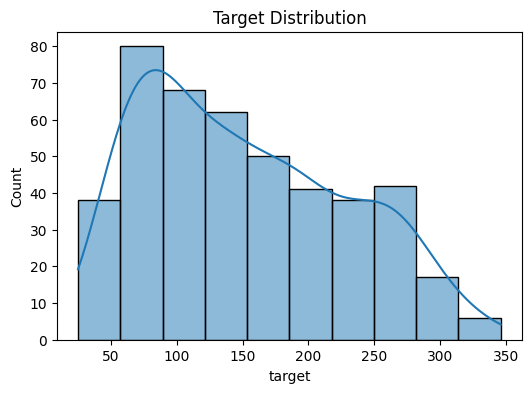

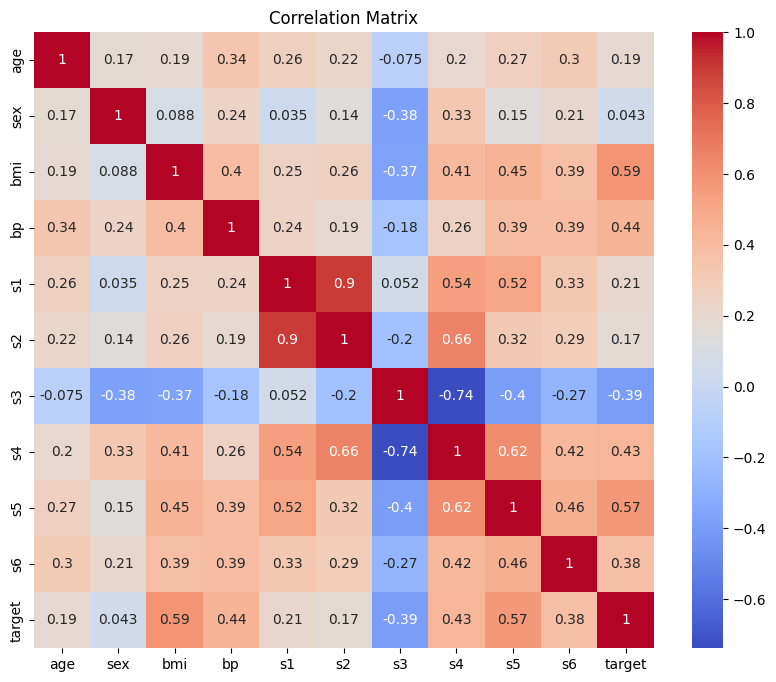

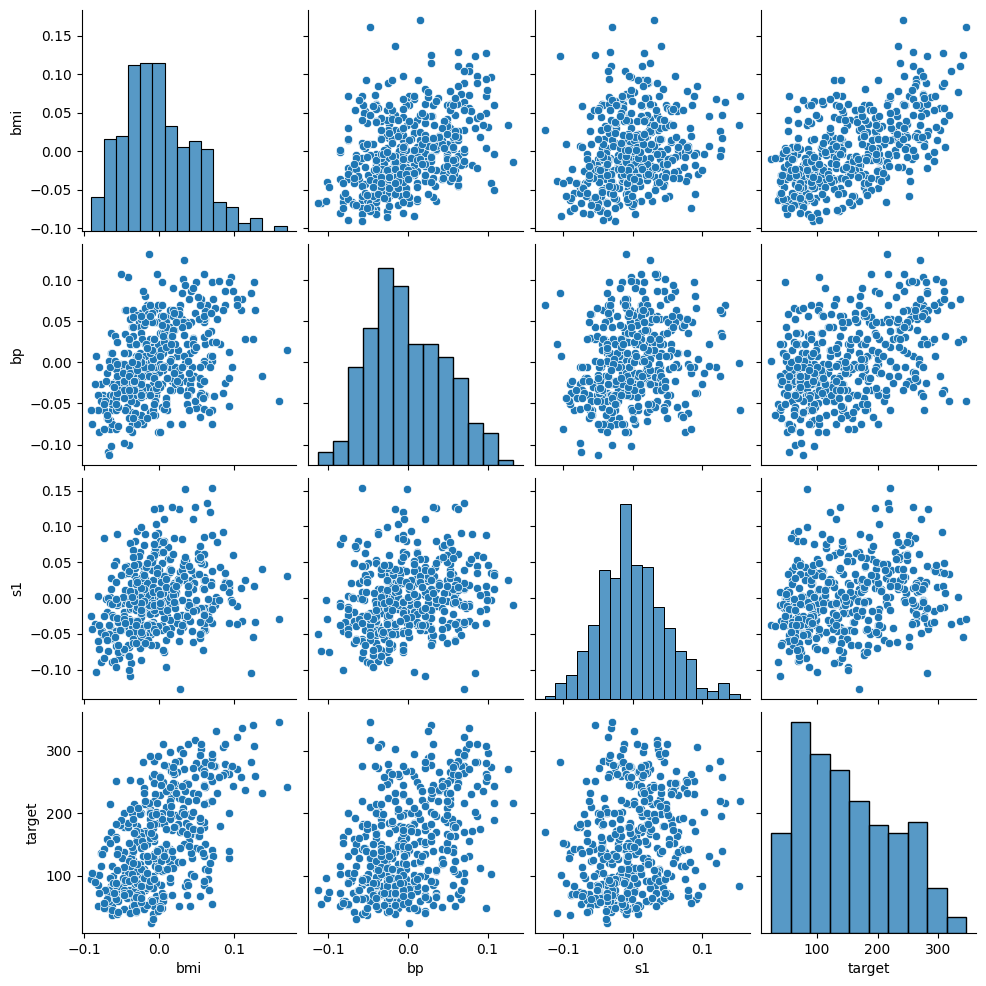

In [3]:
# Distribution of target
plt.figure(figsize=(6,4))
sns.histplot(df['target'], kde=True)
plt.title("Target Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Pairplot (important features)
sns.pairplot(df[['bmi', 'bp', 's1', 'target']])
plt.show()

- Features like BMI, BP, and S1 show strong correlation with diabetes progression.
- Target variable is moderately distributed (not highly skewed).

### 3. Building ANN Model

- Input layer = number of features (10)
- Hidden layer = learns patterns
- Output layer = 1 neuron (regression)

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(X_scaled.shape[1],)),  
    Dense(64, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

### 4. Training the ANN Model
- Split data → train/test
- Loss = Mean Squared Error (best for regression)
- Optimizer = Adam (fast & adaptive)

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 31437.4863 - mae: 158.3779 - val_loss: 22344.9824 - val_mae: 133.6186
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 31342.9512 - mae: 158.1102 - val_loss: 22277.8027 - val_mae: 133.3954
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 31242.3340 - mae: 157.8329 - val_loss: 22210.0781 - val_mae: 133.1683
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 31140.7129 - mae: 157.5551 - val_loss: 22139.7891 - val_mae: 132.9347
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 31038.0605 - mae: 157.2638 - val_loss: 22065.4785 - val_mae: 132.6922
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 30919.5781 - mae: 156.9479 - val_loss: 21987.8652 - val_mae: 132.4372
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 30796.9824 - mae: 156.6176 - val_loss: 21904.5117 - val_mae: 132.1677
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 30660.3223 - mae: 156.2483 - val_loss: 21815.8

##### Plot Training Performance

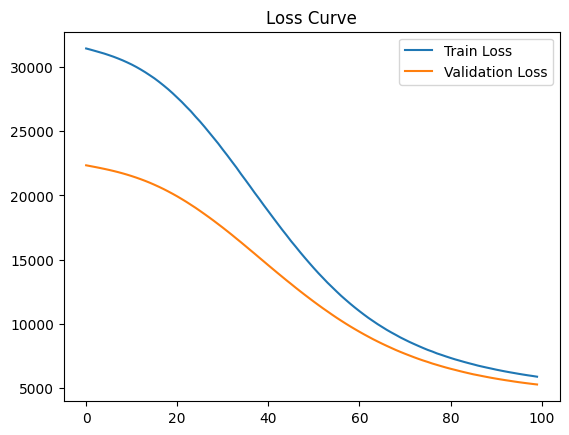

In [8]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

### 5. Evaluating the Model

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Mean Squared Error: 5817.134752214119
R2 Score: -0.09795548114355612


- Lower MSE → better predictions
- R² closer to 1 → better model

### 6. Improving the Model

- More hidden layers
- Dropout (avoid overfitting)
- Different neurons

In [10]:
from tensorflow.keras.layers import Dropout

improved_model = Sequential([
    Input(shape=(X_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

improved_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
history2 = improved_model.fit(
    X_train, y_train,
    epochs=150,
    validation_split=0.2,
    batch_size=32,
    verbose=1
)


Epoch 1/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 31301.5957 - mae: 158.0214 - val_loss: 22171.0098 - val_mae: 132.9874
Epoch 2/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 30928.5879 - mae: 156.8898 - val_loss: 21841.1152 - val_mae: 131.7986
Epoch 3/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 30422.4297 - mae: 155.4106 - val_loss: 21413.3574 - val_mae: 130.2551
Epoch 4/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 29753.7520 - mae: 153.3331 - val_loss: 20832.8066 - val_mae: 128.1678
Epoch 5/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 28807.7520 - mae: 150.5074 - val_loss: 20061.2402 - val_mae: 125.3572
Epoch 6/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 27507.4238 - mae: 146.6274 - val_loss: 19063.7148 - val_mae: 121.6732
Epoch 7/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 25903.3867 - mae: 141.6037 - val_loss: 17813.8945 - val_mae: 116.9553
Epoch 8/150
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 23865.6484 - mae: 135.0510 - val_loss: 16280.6

##### Evaluate Improved Model

In [11]:
y_pred2 = improved_model.predict(X_test)

mse2 = mean_squared_error(y_test, y_pred2)
r22 = r2_score(y_test, y_pred2)

print("Improved MSE:", mse2)
print("Improved R2:", r22)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Improved MSE: 2773.8210560231237
Improved R2: 0.4764549624687987


##### Improvements made:
- Increased neurons (64 → 128)
- Added second hidden layer
- Introduced Dropout (0.2)
##### Result:
- Reduced MSE
- Improved R² score
- Model generalizes better

### 7. Comparison & Conclusion

The improved ANN model significantly outperformed the initial model. The Mean Squared Error decreased from <span style="color:red">5817.13 </span> to <span style="color:red"> 2773.82 </span>,indicating a substantial reduction in prediction error. Additionally, the R² score improved from <span style="color:red"> -0.0979 </span> to <span style="color:red">0.4764 </span>, showing that the enhanced model is able to explain nearly 48% of the variance in the target variable. This demonstrates that the modifications led to better learning and generalization.

##### The performance improved due to:

- Increasing the number of neurons (better feature learning)
- Adding an extra hidden layer (captures complex relationships)
- Using Dropout (reduces overfitting and improves generalization)
- Training for more epochs
#### Conclusion
- ANN successfully modeled diabetes progression.
- Features like BMI and BP significantly influence the outcome.
- Improved architecture resulted in better performance.
- Model can assist in predicting disease progression and supporting medical decisions.